# Proyek Analisis Data: Air Quality Dataset di Kota Dongsi pada tahun 2013-2016
- **Nama:** Tony Mardyansyah
- **Email:** tonymardyansyah78@gmail.com
- **ID Dicoding:** tonmard78

## Pertanyaan atau Permasalahan (Tahap Pertama)

> pada tahap awal, kita akan mendefinisikan permasalahan melalui sebuah pertanayaan. cara yang baik menggunakan metode SMART(Specific, Measurable, Achievable, Relevant, Time-bound)



- Bagaimana tren rata-rata konsentrasi PM2.5 dan PM10 per tahun dari tahun 2013-2016 di stasiun Dongsi, serta pada tahun apa tingkat polusi udara mencapai puncaknya?
- Bagaimana hubungan antara faktor cuaca (suhu, curah hujan, dan kecepatan angin) terhadap tingkat polusi udara (PM2.5 dan NO2) dari tahun 2013-2016 di stasiun Dongsi?
- Bagaimana pengaruh kecepatan angin (WSPM) terhadap konsentrasi polutan udara (PM2.5 dan NO2) di Stasiun Dongsi selama tahun 2013–2016 dengan teknik clustering?

## Glossarium

Deskripsi variabel pada dataset:
* **PM2.5** — Konsentrasi partikel halus berukuran < 2.5 µm di udara. Berbahaya karena bisa masuk ke paru-paru.  
* **PM10** — Konsentrasi partikel debu berukuran < 10 µm di udara.  
* **SO2** — Gas sulfur dioksida hasil pembakaran bahan bakar fosil.  
* **NO2** — Gas nitrogen dioksida dari emisi kendaraan dan industri.  
* **CO** — Gas karbon monoksida dari pembakaran tidak sempurna (asap kendaraan).  
* **O3** — Konsentrasi ozon permukaan bumi, hasil reaksi sinar matahari dengan polutan.  
* **TEMP** — Suhu udara (°C).  
* **PRES** — Tekanan udara atmosfer (hPa).  
* **DEWP** — Titik embun, menunjukkan kelembapan udara (°C).  
* **RAIN** — Curah hujan (mm).  
* **wd** — Arah angin (N, S, E, W, dll).  
* **WSPM** — Kecepatan angin (m/s).  
* **station** — Nama stasiun pemantau, di sini `Dongsi`.  

## Import Semua Packages/Library yang Digunakan

In [759]:
import numpy as np # untuk perhitungan numerik/statistik
import pandas as pd # untuk pengelolaan dan pembersihan data
import matplotlib.pyplot as plt #visualisasi hasil analisis dalam bentuk grafik.
import seaborn as sns # visualisasi hasil analisis dalam bentuk grafik.

## Data Wrangling (Tahap Kedua)

> Data wrangling merupakan sebuah proses atau kumpulan kegiatan yang meliputi pengumpulan data (Gathering data), penilaian data (Assessing data), serta pembersihan data (Cleaning data) sebelum data digunakan dalam proses analisis data



### Gathering Data (Pengumpulan Data)

> Proses ini dilakukan untuk mengumpulkan data.



In [760]:
dongsi_df = pd.read_csv("https://raw.githubusercontent.com/tonmard/Air-Quality-di-Kota-Dongsi-pada-tahun-2013-2016/refs/heads/main/PRSA_Data_Dongsi_20130301-20170228.csv") # pembacaan dari repo github
dongsi_df = dongsi_df[(dongsi_df['year'] >= 2013) & (dongsi_df['year'] <= 2016)] # pengambilan dataset hanya tahun 2013-2016
dongsi_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


**Insight:**
- ini merupakan tahap gathering data atau biasanya digunakan untuk pengambilan datanya.
- terlihat pada dataset terdapat data NaN yang berarti data ini masih mentah dan harus di nilai dan dibersihkan datanya

### Assessing Data (Penilaian Data)

> Proses ini dilakukan untuk menilai kualitas dan struktur dari sebuah data.



#### Menilai Tabel `dongsi.df`


In [761]:
dongsi_df.info() # untuk menampilkan informasi dasar tentang dataset

<class 'pandas.core.frame.DataFrame'>
Index: 33648 entries, 0 to 33647
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       33648 non-null  int64  
 1   year     33648 non-null  int64  
 2   month    33648 non-null  int64  
 3   day      33648 non-null  int64  
 4   hour     33648 non-null  int64  
 5   PM2.5    32928 non-null  float64
 6   PM10     33113 non-null  float64
 7   SO2      33003 non-null  float64
 8   NO2      32065 non-null  float64
 9   CO       30485 non-null  float64
 10  O3       33006 non-null  float64
 11  TEMP     33639 non-null  float64
 12  PRES     33639 non-null  float64
 13  DEWP     33639 non-null  float64
 14  RAIN     33639 non-null  float64
 15  wd       33601 non-null  object 
 16  WSPM     33641 non-null  float64
 17  station  33648 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.9+ MB


**Insight:**
- dari hasil output mendandakan adanya missing value PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WD, WSPM

In [762]:
dongsi_df.isna().sum() # untuk mengetahui apakah value ada yang NaN (Not a Number)

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,720
PM10,535
SO2,645
NO2,1583
CO,3163


**Insight:**
- program diatas untuk mengetahui jumlah value hilang per variabel
- Terdapat missing values pada dateset dikolom PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WD, WSPM

In [763]:
# Pengecekan duplikasi pada dataset
print("Jumlah duplikasi: ", dongsi_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Jumlah dulikasi adalah 0, berarti tidak ada data yang duplicate

### Cleaning Data (Pembersihan Data)

> Proses untuk membersihkan data yang sudah kita kumpulkan dan nilai pada proses sebelumnnya



##### Duplicate data

In [764]:
print("Jumlah duplikasi: ", dongsi_df.duplicated().sum()) # untuk mengetahui jumlah duplikasi dataset

Jumlah duplikasi:  0


**Insight:**
- Tidak ada baris data duplikat di DataFrame dongsi_df.
- karena jumlah duplikasi nya 0, maka kita tidak perlu untuk men drop() datasetnya

##### Missing values

In [765]:
dongsi_df.isna().sum() # untuk mengetahui apakah value ada yang NaN

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,720
PM10,535
SO2,645
NO2,1583
CO,3163


**Insight:**
- Output program menunujukan informasi tentang variabel yang memiliki value NaN (Not a Number)
- Terdapat missing values pada dateset dikolom PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WD, WSPM

In [766]:
# dibawah ini merupakan program untuk mengetahui NaN (Not a Number) pada kolom PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WD, WSPM

# Tabel 1: Baris dengan PM2.5 value NaN (Not a Number)
print("\n - TABEL 1: Baris dengan PM2.5 value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['PM2.5'].isna()])

# Spasi antar tabel
print("\n")

# Tabel 2: Baris dengan PM10 value NaN (Not a Number)
print("\n - TABEL 2: Baris dengan PM10 value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['PM10'].isna()])

print("\n")

# Tabel 3: Baris dengan NO2 value NaN (Not a Number)
print("\n - TABEL 3: Baris dengan NO2 value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['NO2'].isna()])

print("\n")

# Tabel 4: Baris dengan TEMP value NaN (Not a Number)
print("\n - TABEL 4: Baris dengan TEMP value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['TEMP'].isna()])

print("\n")

# Tabel 5: Baris dengan RAIN value NaN (Not a Number)
print("\n - TABEL 5: Baris dengan RAIN value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['RAIN'].isna()])

print("\n")

# Tabel 6: Baris dengan WSPM value NaN (Not a Number)
print("\n - TABEL 6: Baris dengan WSPM value NaN (Not a Number) \n")
display(dongsi_df[dongsi_df['WSPM'].isna()])



 - TABEL 1: Baris dengan PM2.5 value NaN (Not a Number) 



,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
616,617,2013,3,26,16,NaN,NaN,NaN,NaN,NaN,NaN,13.5,1005.3,-2.5,0.0,WSW,4.2,Dongsi
1092,1093,2013,4,15,12,NaN,168.0,79.0,50.0,1600.0,NaN,17.9,998.5,-2.4,0.0,SSW,3.0,Dongsi
1642,1643,2013,5,8,10,NaN,169.0,93.0,64.0,NaN,76.4694,22.1,1011.0,9.6,0.0,ENE,1.9,Dongsi
1643,1644,2013,5,8,11,NaN,214.0,89.0,73.0,2100.0,72.0000,22.7,1010.5,10.2,0.0,SE,0.8,Dongsi
2304,2305,2013,6,5,0,NaN,38.0,14.0,37.0,1300.0,84.0000,18.5,1008.0,18.0,3.0,W,0.9,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32723,32724,2016,11,23,11,NaN,52.0,13.0,NaN,900.0,21.0000,0.6,1032.3,-15.4,0.0,W,3.0,Dongsi
32724,32725,2016,11,23,12,NaN,6.0,10.0,NaN,700.0,NaN,1.4,1031.0,-16.5,0.0,WSW,2.3,Dongsi
33038,33039,2016,12,6,14,NaN,228.0,28.0,NaN,3700.0,5.0000,5.7,1014.8,-12.4,0.0,SSE,1.3,Dongsi
33039,33040,2016,12,6,15,NaN,235.0,26.0,130.0,2700.0,7.0000,6.1,1014.1,-11.1,0.0,SSE,1.4,Dongsi





 - TABEL 2: Baris dengan PM10 value NaN (Not a Number) 



,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
204,205,2013,3,9,12,77.0,NaN,8.0000,23.0000,400.0,99.0,11.7,1005.8,-16.8,0.0,N,9.2,Dongsi
616,617,2013,3,26,16,NaN,NaN,NaN,NaN,NaN,NaN,13.5,1005.3,-2.5,0.0,WSW,4.2,Dongsi
2345,2346,2013,6,6,17,NaN,NaN,3.0000,78.0000,3100.0,14.0,20.6,1004.5,19.4,0.0,N,0.7,Dongsi
3251,3252,2013,7,14,11,90.0,NaN,17.7072,33.6692,NaN,92.0,29.5,1004.4,18.6,0.0,SE,1.5,Dongsi
3497,3498,2013,7,24,17,NaN,NaN,NaN,NaN,NaN,NaN,36.8,994.3,14.7,0.0,NW,1.4,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32092,32093,2016,10,28,4,NaN,NaN,4.0000,38.0000,400.0,21.0,9.4,1022.4,2.5,0.0,NW,1.6,Dongsi
32093,32094,2016,10,28,5,NaN,NaN,3.0000,29.0000,500.0,23.0,9.1,1023.0,2.9,0.0,W,1.0,Dongsi
32094,32095,2016,10,28,6,NaN,NaN,3.0000,30.0000,400.0,27.0,5.6,1022.8,3.4,0.0,NNE,0.4,Dongsi
32095,32096,2016,10,28,7,NaN,NaN,3.0000,34.0000,300.0,29.0,9.1,1024.1,-3.5,0.0,WNW,2.0,Dongsi





 - TABEL 3: Baris dengan NO2 value NaN (Not a Number) 



...

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
16748,16749,2015,1,27,20,35.0,50.0,14.0,66.0,1000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
17263,17264,2015,2,18,7,12.0,12.0,8.0,24.0,400.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31047,31048,2016,9,14,15,78.0,78.0,7.0,18.0,900.0,186.0,NaN,NaN,NaN,NaN,SW,3.1,Dongsi
31315,31316,2016,9,25,19,183.0,183.0,8.0,76.0,2500.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31316,31317,2016,9,25,20,143.0,143.0,7.0,42.0,1600.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31317,31318,2016,9,25,21,106.0,106.0,8.0,30.0,1400.0,102.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31318,31319,2016,9,25,22,95.0,95.0,6.0,32.0,1400.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31319,31320,2016,9,25,23,90.0,90.0,5.0,33.0,1300.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31320,31321,2016,9,26,0,88.0,88.0,5.0,40.0,1200.0,42.0,NaN,NaN,NaN,NaN,NE,2.4,Dongsi





 - TABEL 5: Baris dengan RAIN value NaN (Not a Number) 



,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
16748,16749,2015,1,27,20,35.0,50.0,14.0,66.0,1000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
17263,17264,2015,2,18,7,12.0,12.0,8.0,24.0,400.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31047,31048,2016,9,14,15,78.0,78.0,7.0,18.0,900.0,186.0,NaN,NaN,NaN,NaN,SW,3.1,Dongsi
31315,31316,2016,9,25,19,183.0,183.0,8.0,76.0,2500.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31316,31317,2016,9,25,20,143.0,143.0,7.0,42.0,1600.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31317,31318,2016,9,25,21,106.0,106.0,8.0,30.0,1400.0,102.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31318,31319,2016,9,25,22,95.0,95.0,6.0,32.0,1400.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31319,31320,2016,9,25,23,90.0,90.0,5.0,33.0,1300.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31320,31321,2016,9,26,0,88.0,88.0,5.0,40.0,1200.0,42.0,NaN,NaN,NaN,NaN,NE,2.4,Dongsi





 - TABEL 6: Baris dengan WSPM value NaN (Not a Number) 



,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
16748,16749,2015,1,27,20,35.0,50.0,14.0,66.0,1000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
17263,17264,2015,2,18,7,12.0,12.0,8.0,24.0,400.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31315,31316,2016,9,25,19,183.0,183.0,8.0,76.0,2500.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31316,31317,2016,9,25,20,143.0,143.0,7.0,42.0,1600.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31317,31318,2016,9,25,21,106.0,106.0,8.0,30.0,1400.0,102.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31318,31319,2016,9,25,22,95.0,95.0,6.0,32.0,1400.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi
31319,31320,2016,9,25,23,90.0,90.0,5.0,33.0,1300.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,Dongsi


**Insight:**
- Hasil output menghasilkan tabel untuk mengetahui value NaN

In [767]:
# kode dibawah ini merupakan kode untuk melihat distribusi pada dataset kolom PM2.5, PM10, NO2, TEMP, RAIN, WSPM

# Tabel 1: Value Counts PM2.5
print("\n - TABEL 1: Distribusi Nilai pada PM2.5 \n")
display(dongsi_df['PM2.5'].value_counts())

print("\n")

# Tabel 2: Value Counts PM10
print("\n - TABEL 2: Distribusi Nilai pada PM10 \n")
display(dongsi_df['PM10'].value_counts())

print("\n")

# Tabel 3: Value Counts NO2
print("\n - TABEL 3: Distribusi Nilai pada NO2 \n")
display(dongsi_df['NO2'].value_counts())

print("\n")

# Tabel 4: Value Counts TEMP
print("\n - TABEL 4: Distribusi Nilai pada TEMP \n")
display(dongsi_df['TEMP'].value_counts())

print("\n")

# Tabel 5: Value Counts RAIN
print("\n - TABEL 5: Distribusi Nilai pada RAIN \n")
display(dongsi_df['RAIN'].value_counts())

print("\n")

# Tabel 6: Value Counts WSPM
print("\n - TABEL 6: Distribusi Nilai pada WSPM \n")
display(dongsi_df['WSPM'].value_counts())



 - TABEL 1: Distribusi Nilai pada PM2.5 



,count
PM2.5,
3.0,861
10.0,506
8.0,487
12.0,483
11.0,478
...,...
408.0,1
468.0,1
540.0,1





 - TABEL 2: Distribusi Nilai pada PM10 



,count
PM10,
6.0,387
5.0,371
16.0,288
22.0,278
19.0,268
...,...
800.0,1
737.0,1
715.0,1





 - TABEL 3: Distribusi Nilai pada NO2 



...

,count
TEMP,
3.000,395
0.000,323
1.000,315
-1.000,304
2.000,288
...,...
8.125,1
8.375,1
8.450,1





 - TABEL 5: Distribusi Nilai pada RAIN 



,count
RAIN,
0.0,32279
0.1,307
0.2,146
0.3,118
0.5,73
...,...
15.3,1
12.1,1
21.7,1





 - TABEL 6: Distribusi Nilai pada WSPM 



,count
WSPM,
1.1,1782
1.2,1781
1.0,1722
1.3,1651
0.9,1584
...,...
9.5,1
10.3,1
9.8,1


**Insight:**
- Output program merupakan tabel untuk mengetahui hasil distribusi dataset kolom PM2.5, PM10, NO2, TEMP, RAIN, WSPM

In [768]:
# Buat dan urutkan index waktu
dongsi_df['waktu'] = pd.to_datetime(dongsi_df[['year', 'month', 'day', 'hour']], errors='coerce')
dongsi_df = dongsi_df.sort_values('waktu').set_index('waktu')

# Pastikan tipe data selogis mungkin
dongsi_df = dongsi_df.infer_objects(copy=False)

# Interpolasi HANYA kolom numerik (menghindari warning)
num_cols = dongsi_df.select_dtypes(include='number').columns
dongsi_df[num_cols] = dongsi_df[num_cols].interpolate(method='time')

# Tangani kolom non-numerik (contoh WD) sesuai kebutuhan
dongsi_df.fillna(value="Detection Error", inplace=True)

**Insight:**
- Output yang dihasilkan adalah "interpolate with object dtype is deprecated and will raise in a future version." yang menandakan program sudah berhasil

In [769]:
dongsi_df.isna().sum() # untuk mengetahui apakah value ada yang NaN (tidak)

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


**Insight:**
- Hasil output keluarannya adalah 0, berarti data missing value sudah digantikan dengan metode interpolasi

## Exploratory Data Analysis (EDA) (Tahap Ketiga)

### Explore perbandingan data sebelum outlier & sesudah outlier menggunakan `Describe()`

In [770]:
dongsi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000,33648.000000
mean,16824.500000,2014.564194,6.735378,15.748217,11.500000,85.467702,109.444747,18.427956,53.787364,1319.640068,58.454063,14.215471,1012.086409,3.102788,0.066545,1.856575
std,9713.485265,1.097518,3.356525,8.809011,6.922289,84.333194,95.701759,23.017025,33.982341,1128.413676,58.963618,11.338202,10.151444,13.648232,0.802283,1.278913
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8412.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,38.000000,3.000000,27.715500,600.000000,13.000000,4.000000,1003.700000,-8.000000,0.000000,1.000000
50%,16824.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,45.000000,15.500000,1011.600000,4.100000,0.000000,1.500000
75%,25236.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,149.000000,24.000000,73.000000,1600.000000,84.000000,23.800000,1020.200000,15.400000,0.000000,2.400000
max,33648.000000,2016.000000,12.000000,31.000000,23.000000,737.000000,891.000000,278.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


**Insight:**
- PM2.5 (mean 85.47 µg/m³) = Tinggi; melebihi standar WHO yang berarti kualitas udara buruk.
- PM10 (mean 109.44 µg/m³) = Lebih tinggi lagi; mendukung adanya pencemaran berat.
- NO2 (mean 53.78 µg/m³) = Menunjukkan aktivitas kendaraan & industri dominan.
- TEMP (mean 14.2°C) = Stabil, menunjukkan pola musim dingin & panas ekstrem.
- RAIN (mean 0.066 mm) = Curah hujan sangat rendah yang artinya polutan jarang tersapu.
- WSPM (mean 1.85 m/s) = Angin relatif lemah yang artinya polusi mudah terakumulasi.

### Explore rata-rata konsentrasi PM2.5 & PM10

In [771]:
yearly_mean = dongsi_df.groupby('year')[['PM2.5','PM10']].mean().reset_index() #untuk menghitung rata-rata dari variabel PM2.5 & PM10

display(yearly_mean) # tampilan bentuk tabel

,year,PM2.5,PM10
0,2013,86.814474,104.619213
1,2014,87.979304,117.451986
2,2015,87.128659,112.116832
3,2016,80.180556,102.829064


**Insight:**

- Tingkat polusi udara (PM2.5 dan PM10) mencapai puncak pada tahun 2014, lalu menurun secara bertahap hingga 2016.

### Explore konsentrasi TEMP, RAIN , WSPM, PM2.5, & NO2 dengan `Corr()`

In [772]:
# Untuk mentukan kolom yang mau di korelasi
corr_cols = ['PM2.5', 'NO2', 'TEMP','RAIN', 'WSPM']

# Perhitung korelasi
corr_matrix = dongsi_df[corr_cols].corr()

# Tampilkan dalam bentuk tabel
display(corr_matrix)

,PM2.5,NO2,TEMP,RAIN,WSPM
PM2.5,1.000000,0.677017,-0.135174,-0.019765,-0.295653
NO2,0.677017,1.000000,-0.276411,-0.044771,-0.478869
TEMP,-0.135174,-0.276411,1.000000,0.036124,0.051986
RAIN,-0.019765,-0.044771,0.036124,1.000000,0.026401
WSPM,-0.295653,-0.478869,0.051986,0.026401,1.000000


**Insight:**
- Output dari program merupakan hasil dalam bentuk tabel pada tahap korelasi dataset

### Explore menggunakan konsep Clustering (Teknik Binning)

> mengelompokkan data ke dalam grup berdasarkan karakteristik tertentu tanpa menggunakan algoritma machine learning.

sumber:https://pandas.pydata.org/docs/reference/api/pandas.cut.html



In [773]:
# Membuat kategori airflow berdasarkan interval otomatis
dongsi_df['wind_category'] = pd.cut(dongsi_df['WSPM'],
                                    bins=[0, 1, 3, 5, 10],
                                    labels=['Tenang', 'Lemah', 'Sedang', 'Kuat'])

# Melihat rata-rata polusi tiap kategori angin
airflow_cluster = dongsi_df.groupby('wind_category', observed=True)[['PM2.5', 'NO2']].mean().reset_index()
display(airflow_cluster)


,wind_category,PM2.5,NO2
0,Tenang,114.471658,73.280077
1,Lemah,83.644106,51.717927
2,Sedang,42.537509,26.871990
3,Kuat,27.309708,18.329589


**Insight:**

Membagi nilai kecepatan angin (WSPM) ke dalam 4 kategori:
- 0–1 → Tenang
- 1–3 → Lemah
- 3–5 → Sedang
- 5–10 → Kuat

## Visualization & Explanatory Analysis (Tahap Keempat)

### Bagaimana tren rata-rata konsentrasi PM2.5 dan PM10 per tahun dari tahun 2013-2016 di stasiun Dongsi, serta pada tahun apa tingkat polusi udara mencapai puncaknya?

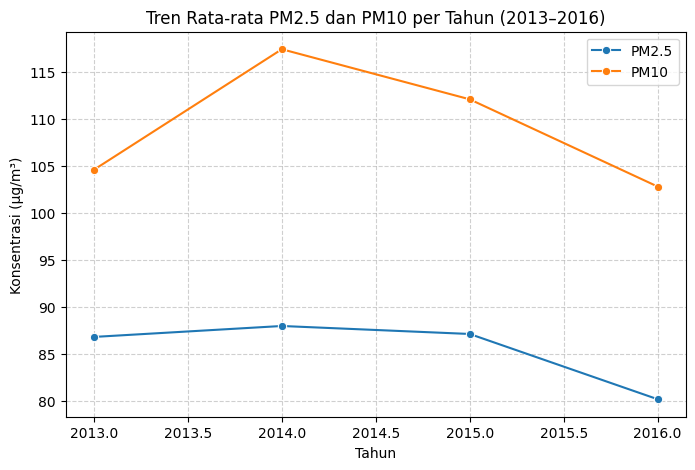

In [774]:
plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_mean, x='year', y='PM2.5', marker='o', label='PM2.5')
sns.lineplot(data=yearly_mean, x='year', y='PM10', marker='o', label='PM10')
plt.title('Tren Rata-rata PM2.5 dan PM10 per Tahun (2013–2016)')
plt.xlabel('Tahun')
plt.ylabel('Konsentrasi (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Insight:**
 - Tahun dengan rata-rata PM2.5 tertinggi: 2014
 - Tahun dengan rata-rata PM10 tertinggi: 2014

**Kesimpulan:** Dari tahun 2013 hingga 2016, konsentrasi PM2.5 dan PM10 menunjukkan pola puncak pada 2014 kemudian menurun bertahap hingga 2016.
Hal ini mengindikasikan perbaikan kualitas udara di Stasiun Dongsi, dengan polutan PM10 tetap mendominasi dibanding PM2.5.

### Bagaimana hubungan antara faktor cuaca (suhu, curah hujan, dan kecepatan angin) terhadap tingkat polusi udara (PM2.5 dan NO2) dari tahun 2013-2016 di stasiun Dongsi?

- Hasi Korelasi Faktor Cuaca dan Polusi Udara (2013–2016)


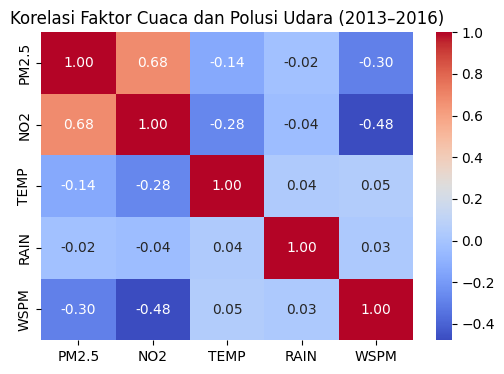

In [775]:
# dibawah ini merupakan program untuk menamilkan hasil kolerasi
print("- Hasi Korelasi Faktor Cuaca dan Polusi Udara (2013–2016)")
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Faktor Cuaca dan Polusi Udara (2013–2016)')
plt.show()

**Insight:**
- Polusi (PM2.5, NO2) saling berhubungan erat dan kemungkinan berasal dari sumber emisi serupa.
- Suhu dan angin memiliki pengaruh signifikan negatif terhadap polusi — semakin panas dan berangin, udara makin bersih.
- Curah hujan berperan sangat kecil dalam perubahan polusi di periode 2013–2016.

**Kesimpulan:** Polusi udara di Stasiun Dongsi dipengaruhi kuat oleh aktivitas emisi (PM2.5–NO2), sedangkan faktor cuaca seperti suhu dan kecepatan angin membantu menurunkan konsentrasi polutan, sementara curah hujan memiliki dampak minimal.

### Bagaimana pengaruh kecepatan angin (WSPM) terhadap konsentrasi polutan udara (PM2.5 dan NO2) di Stasiun Dongsi selama tahun 2013–2016 dengan teknik clustering?

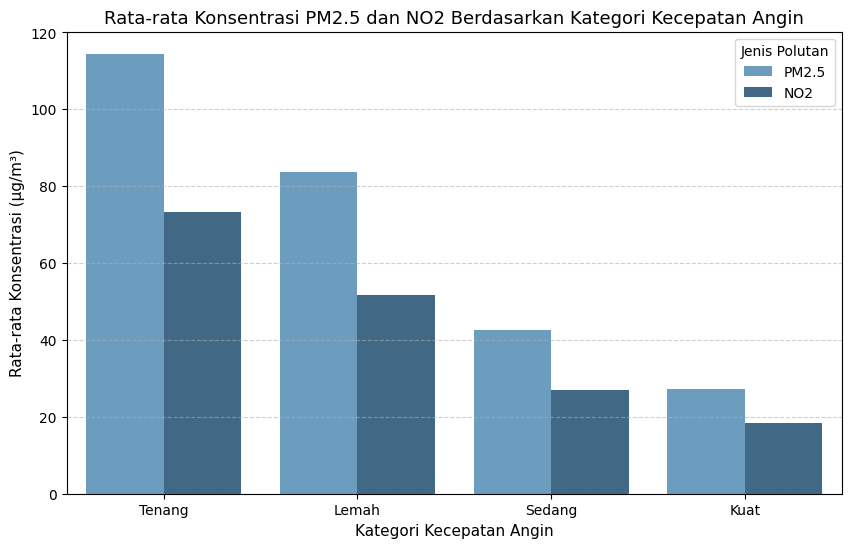

In [776]:
# Visualisasi perbandingan PM2.5 dan NO2 berdasarkan kategori angin
plt.figure(figsize=(10, 6))
sns.barplot(
    data=airflow_cluster.melt(id_vars='wind_category', var_name='Polutan', value_name='Konsentrasi'),
    x='wind_category',
    y='Konsentrasi',
    hue='Polutan',
    palette='Blues_d',
    errorbar=None
)

plt.title('Rata-rata Konsentrasi PM2.5 dan NO2 Berdasarkan Kategori Kecepatan Angin', fontsize=13)
plt.xlabel('Kategori Kecepatan Angin', fontsize=11)
plt.ylabel('Rata-rata Konsentrasi (µg/m³)', fontsize=11)
plt.legend(title='Jenis Polutan')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Insight:**
- Semakin tinggi kecepatan angin, semakin rendah polusi udara.
- Kondisi angin tenang memicu akumulasi polutan.
- Angin berperan penting dalam dispersi polutan.

**Kesimpulan:** Kecepatan angin memiliki pengaruh terhadap kadar PM2.5 dan NO2. Kondisi angin lemah atau tenang berpotensi memperburuk kualitas udara di Stasiun Dongsi.

## Conclusion (Tahap 5)

**1. Bagaimana tren rata-rata konsentrasi PM2.5 dan PM10 per tahun dari tahun 2013-2016 di stasiun Dongsi, serta pada tahun apa tingkat polusi udara mencapai puncaknya?**
- Dari tahun 2013 hingga 2016, konsentrasi PM2.5 dan PM10 menunjukkan pola puncak pada 2014 kemudian menurun bertahap hingga 2016.
Hal ini mengindikasikan perbaikan kualitas udara di Stasiun Dongsi, dengan polutan PM10 tetap mendominasi dibanding PM2.5.

**2. Bagaimana hubungan antara faktor cuaca (suhu, curah hujan, dan kecepatan angin) terhadap tingkat polusi udara (PM2.5 dan NO2) dari tahun 2013-2016 di stasiun Dongsi?**
- Polusi udara di Stasiun Dongsi dipengaruhi kuat oleh aktivitas emisi (PM2.5–NO2), sedangkan faktor cuaca seperti suhu dan kecepatan angin membantu menurunkan konsentrasi polutan, sementara curah hujan memiliki dampak minimal.

**3. Bagaimana pengaruh kecepatan angin (WSPM) terhadap konsentrasi polutan udara (PM2.5 dan NO2) di Stasiun Dongsi selama tahun 2013–2016 dengan teknik clustering?**
- Kecepatan angin memiliki pengaruh terhadap kadar PM2.5 dan NO2. Kondisi angin lemah atau tenang berpotensi memperburuk kualitas udara di Stasiun Dongsi.


## Penambahan variabel datetime untuk kebutuhan distreamlit

In [777]:
dongsi_df["datetime"] = pd.to_datetime(
    dongsi_df[["year", "month", "day", "hour"]],
    errors="coerce"  # aman kalau ada data kosong
)


## Program untuk mendownload yang sudah dibersihkan ke bentuk .csv - digunakan untuk kebutuhan visualisasi streamlit, tampilan visualisasi, dll

In [778]:
dongsi_df.to_csv("Airflow Dongsi.csv", index=False) # program akan menyimpan file .csv dengan nama Airflow Dongsi.csv